In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jedi.api.completion_cache import save_entry
import chaosmagpy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
import math
import scipy
import pandas as pd

In [2]:
def dx(ym, xm, f):
    dxm = np.abs(xm[0, 1] - xm[0, 0])
    der = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dxm)
    der[:, 0] = (f[:, 1] - f[:, -2]) / (2 * dxm)
    der[:, -1] = der[:, 0]
    return der

def dy(ym, xm, f):
    dym = np.abs(ym[1, 0] - ym[0, 0])
    der = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dym)
    der[0, :] = (f[1, :] - f[0, :]) / (dym)
    der[1, :] = (f[-1, :] - f[-2, :]) / (dym)
    return der

def ddy(ym, xm, f):
    dym = np.abs(ym[1, 0] - ym[0, 0])
    der = (np.roll(f, 1, axis=0) - 2 * f + np.roll(f, -1, axis=0)) / (dym ** 2)
    der[0, :] = der[1, :]
    der[-1, :] = der[-2, :]
    return der

def ddx(ym, xm, f):
    dxm = np.abs(xm[0, 1] - xm[0, 0])
    der = (np.roll(f, 1, axis=1) - 2 * f + np.roll(f, -1, axis=1)) / (dxm ** 2)
    der[:, 0] = (f[:, 1] - 2 * f[:, 0] + f[:, -2]) / (dxm ** 2)
    der[:, -1] = der[:, 0]
    return der

def ddxy(ym, xm, f):
    df_dx = dx(ym, xm, f)
    ddf_dxy = dy(ym, xm, df_dx)
    return ddf_dxy

def detH(ddx,ddy):
    derH=(ddx*ddy)
    return derH

def read_gauss_coeffs(filename, target_year, lmax=25):
  # Read Gauss coefficients for a specified year from a HISTKALMAG-format file.
  # The output Gauss coefficients gsh and hsh are ordered according to (l, m).
    with open(filename, 'r') as f:
        lines = f.readlines()

    years = list(map(float, lines[0].strip().split()))
    if target_year not in years:
        raise ValueError(f"No target_year {target_year}")
    idx = years.index(target_year)

    coeff_lines = lines[1:len(lines)]
    coeffs = [list(map(float, line.strip().split())) for line in coeff_lines]

    coeffs_at_year = [row[idx] for row in coeffs]
    gsh = []
    hsh = []
    i = 0
    for l in range(1, lmax + 1):
        for m in range(0, l + 1):
            if m == 0:
                gsh.append(coeffs_at_year[i])
                i+=1
                hsh.append(0.0)
            else:
                gsh.append(coeffs_at_year[i])
                i+=1
                hsh.append(coeffs_at_year[i])
                i += 1
    return np.array(gsh), np.array(hsh)

def magnetic_field(gsh,hsh,lmax,r,lats,lons):
    a=6371.2
    pi            = math.pi
    # lats          =  np.linspace(1., 179., num=181)
    # lons          =  np.linspace(-180., 180., num=181)
    lons2d,lats2d = np.meshgrid(lons,lats)
    phi           = lons2d
    cost2d        = np.cos((lats2d)*np.pi/180)
    i             = 0
    br            = np.zeros((cost2d.shape))
    bphi          = np.zeros((cost2d.shape))
    btheta        = np.zeros((cost2d.shape))
    for l in np.arange(1,lmax+1,1):
        for m in np.arange(0,l+1,1):
            g=gsh[i]
            h=hsh[i]
            #calculate schmidt
            if m  == 0:
                schmidt = 1.0
            else:
                schmidt = ((-1.0)**m)*np.sqrt(2.0*math.factorial(l-m)/math.factorial(l+m))
            lagendre     = scipy.special.lpmv(m, l, cost2d)
            lagendre_    = scipy.special.lpmv(m, l-1, cost2d)
            div_lagendre = (l*cost2d*lagendre-(l+m)*lagendre_)/np.sqrt(1-cost2d**2)
            br           = br     + schmidt*(float(l)+1.0)*((a/r)**(l+2))*lagendre*(g*np.cos(float(m)*phi*pi/180.0)
                                                                                    +h*np.sin(float(m)*phi*pi/180.0))
            bphi         = bphi   + schmidt*(m/np.sin((lats2d)*pi/180))*((a/r)**(l+2))*lagendre*(-g*np.sin(float(m)*phi*pi/180.0)
                                                                                                    +h*np.cos(float(m)*phi*pi/180.0))
            btheta       = btheta + schmidt*((a/r)**(l+2))*(div_lagendre)*(g*np.cos(float(m)*phi*pi/180.0)+h*np.sin(float(m)*phi*pi/180.0))
            i+=1
    return br,bphi,btheta,lons2d,lats2d

def calculate_integral(B):
    phi_range = np.linspace(0, 2 * np.pi, B.shape[1] + 1) 
    theta_range = np.linspace(0, np.pi, B.shape[0] + 1)  

    integrals = [0, 0]
    theta_min = np.deg2rad(25)
    theta_max = np.deg2rad(155)
    region_boundaries = [
        [(0, 2 * np.pi), (0, theta_min)],
        [(0, 2 * np.pi), (theta_max, np.pi)] ]
    for i, region in enumerate(region_boundaries):
        for j in range(len(phi_range) - 1):
            for k in range(len(theta_range) - 1):
                phi_lower = phi_range[j]
                phi_upper = phi_range[j + 1]
                theta_lower = theta_range[k]
                theta_upper = theta_range[k + 1]
                sin_theta = np.sin((theta_lower + theta_upper) / 2)
                d_phi = phi_upper - phi_lower
                d_theta = theta_upper - theta_lower

                if region[0][0] <= (phi_lower + phi_upper) / 2 <= region[0][1] and region[1][0] <= (theta_lower + theta_upper) / 2 <= region[1][1]:
                    integrals[i] += B[k, j] * sin_theta * d_phi * d_theta
    integral = sum(integrals)
    return integral

def F_C_ObO(x, y, fun1, fun2, lev): # main function to Find the Cross points one by one. 
    c_fx = plt.contour(x, y, fun1, levels=[lev])
    c_fy = plt.contour(x, y, fun2, levels=[lev])

    Line_dx = []
    points_dx = []
    paths = c_fx.get_paths()
    polygons = paths[0].to_polygons()

    for i, poly in enumerate(polygons):
        verts = poly
        if abs(verts[-1, 0] - verts[-2, 0]) > 10 or abs(verts[-1, 1] - verts[-2, 1]) > 10:
            zz = 2
        else:
            zz = 1
        points_dx.extend(verts)
        FxLine = []

        for v in range(len(verts) - zz):
            xa, ya = verts[v]
            xb, yb = verts[v + 1]
            xlist = np.array([xa, xb])
            ylist = np.array([ya, yb])

            # Skip if two points are too close (to avoid polyfit failure)
            if np.isclose(xa, xb) and np.isclose(ya, yb):
                continue

            try:
                k, b = np.polyfit([xa, xb], [ya, yb], deg=1)
            except np.linalg.LinAlgError:
                print(f"Warning: polyfit failed for points ({xa}, {ya}) - ({xb}, {yb}), skipped.")
                continue

            k, b = np.polyfit(xlist, ylist, deg=1)
            FxLine.append([k, b, xa, xb, ya, yb])

        Line_dx.append(np.array(FxLine))

    Line_dy = []
    points_dy = []
    paths = c_fy.get_paths()
    polygons = paths[0].to_polygons()

    for i, poly in enumerate(polygons):
        verts = poly
        if abs(verts[-1, 0] - verts[-2, 0]) > 10 or abs(verts[-1, 1] - verts[-2, 1]) > 10:
            zz = 2
        else:
            zz = 1
        points_dy.extend(verts)
        FyLine = []

        for v in range(len(verts) - zz):
            xa, ya = verts[v]
            xb, yb = verts[v + 1]
            xlist = np.array([xa, xb])
            ylist = np.array([ya, yb])

            # Skip if two points are too close (to avoid polyfit failure)
            if np.isclose(xa, xb) and np.isclose(ya, yb):
                continue

            try:
                k, b = np.polyfit([xa, xb], [ya, yb], deg=1)
            except np.linalg.LinAlgError:
                print(f"Warning: polyfit failed for points ({xa}, {ya}) - ({xb}, {yb}), skipped.")
                continue

            k, b = np.polyfit(xlist, ylist, deg=1)
            FyLine.append([k, b, xa, xb, ya, yb])

        Line_dy.append(np.array(FyLine))

    x_cross = []
    y_cross = []

    for n in range(len(Line_dx)):
        Fx = Line_dx[n]
        for m in range(len(Line_dy)):
            Fy = Line_dy[m]
            for p in range(len(Fx[:, 0])):
                k1, b1, x1, x2, y1, y2 = Fx[p, :]
                for q in range(len(Fy[:, 0])):
                    k2, b2, x3, x4, y3, y4 = Fy[q, :]
                    x_c = (b2 - b1) / (k1 - k2)
                    if x_c is not None:
                        # Check if x_c is within the x-range of both line segments
                        in_range_1 = (min(x1, x2) <= x_c <= max(x1, x2))
                        in_range_2 = (min(x3, x4) <= x_c <= max(x3, x4))
                        if in_range_1 and in_range_2:
                            y_c = k1 * x_c + b1
                            if y_c is not None:
                                # Check if y_c is within the y-range of both line segments
                                in_range_3 = (min(y1, y2) <= y_c <= max(y1, y2))
                                in_range_4 = (min(y3, y4) <= y_c <= max(y3, y4))
                                if in_range_3 and in_range_4:
                                    x_cross.append(x_c)
                                    y_cross.append(y_c)

    x_cross = np.array(x_cross)
    y_cross = np.array(y_cross)

    # Keep only points with y in [5, 175]
    mask = (y_cross >= 5) & (y_cross <= 175)
    x_cross = x_cross[mask]
    y_cross = y_cross[mask]

    return x_cross, y_cross

def detH_saddle(DETH, thetam, phim, crossingsX,crossingsY):

    lat_grid = thetam[:, 0]
    lon_grid = phim[0, :]

    interp_func = scipy.interpolate.RegularGridInterpolator((lat_grid, lon_grid), DETH,
                                                            bounds_error=False,
                                                            fill_value=np.nan)
    cross = np.column_stack((crossingsX, crossingsY))
    cross = np.array(cross)
    points_for_interp = cross[:, [1, 0]]
    values = interp_func(points_for_interp)

    pos_mask = values > 0
    neg_mask = values <= 0

    pos_points = points_for_interp[pos_mask]
    neg_points = points_for_interp[neg_mask]

    return pos_points, neg_points

def magnetic_point(gsh, hsh, lmax, r, y, x):
    fi=[]
    for i in range(0,len(y)):
        br,bphi,btheta,_,_=magnetic_field(gsh, hsh, lmax, radius, y[i], x[i])
        fff=np.sqrt(br**2 + bphi**2 + btheta**2)/1000
        fi.append(fff)
    return np.array(fi).squeeze()

In [9]:
from matplotlib.ticker import ScalarFormatter

radius = 6371.
theta = np.linspace(1., 179., num=181)  # colatitude in degrees
phi = np.linspace(0., 360., num=361)  # longitude in degrees
phim, thetam = np.meshgrid(phi, theta)
radiusm = radius * np.ones(phim.shape)
filepath="D:\\work\\origin data\\coeff\\covobsx2.txt"

lmax=14
r=6371
n=1

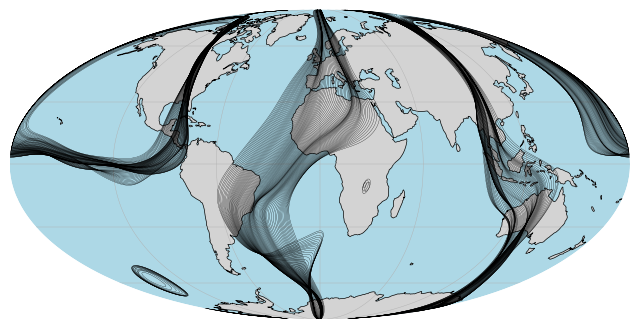

In [13]:
lon_bins = np.arange(0, 361, 5)  
lon_cross_count = {i: 0 for i in range(len(lon_bins) - 1)} 

fig = plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1,projection=ccrs.Mollweide())
ax1.coastlines(linewidth=0.5)
ax1.gridlines(draw_labels=False, linewidth=0.3)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.add_feature(cfeature.LAND, facecolor='lightgray')  
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')  
   
for yr in range(1840,2025,2):
    gsh, hsh = read_gauss_coeffs(filepath, yr, lmax=lmax)
    br,bphi,btheta,lons2d,lats2d=magnetic_field(gsh, hsh, lmax, radius, theta, phi)
    F=np.sqrt(br**2 + bphi**2 + btheta**2)/1000
    F_real = F
    d_x = dx(thetam, phim, F_real)
    d_y = dy(thetam, phim, F_real)
    
    ##########################################

    cs = ax1.contour(phi, 90-theta, d_x, levels=[0],colors='k', linewidths=0.2, linestyles='solid',transform=ccrs.PlateCarree(),zorder=5)
plt.show()